In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Reading Files into DataFrames

* `pd.read_csv('file.csv')` — Reads standard comma-separated text files.
* `pd.read_table('file.txt', sep='\t')` — Reads tab-separated or custom delimiter files.
* `pd.read_excel('file.xlsx', sheet_name='Sheet1')` — Reads Excel spreadsheets.
* `pd.read_json('file.json')` — Parses JSON data into a tabular structure.

In [44]:
# Useful optional parameters:
# index_col='Country' -> sets an existing column as the DataFrame index
# nrows=100           -> reads only the first 100 rows for quick testing
df = pd.read_csv('world_population.csv')

### 2. Pandas Display Configuration: `pd.set_option()` and `pd.reset_option()`

* `display.max_columns`: Maximum columns shown before truncation (`...`). Pass `None` to display all.
* `display.max_rows`: Maximum rows displayed. Pass `None` for all, or an integer (e.g., `20`).
* `display.precision`: Decimal points for floating-point values (display only; does not round actual data).
* `display.width`: Total character width for terminal/console wrapping (useful in VS Code / PyCharm).

In [45]:
# Change a setting
pd.set_option('display.max_rows', None)

# Reset a specific setting back to default
pd.reset_option('display.max_rows')

# Reset ALL display options back to defaults
pd.reset_option('all')

C:\Users\bexru\AppData\Local\Temp\ipykernel_17456\3674029775.py:8: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.reset_option('all')
C:\Users\bexru\AppData\Local\Temp\ipykernel_17456\3674029775.py:8: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.reset_option('all')


### 3. DataFrame Inspection Diagnostics

* `df.info()` — Prints structural summary: row count, column data types, and non-null values.
* `df.describe()` — Calculates summary statistics (mean, std, min, max, quartiles) for numeric columns.
* `df.shape` — Returns a tuple representing dimensional layout `(rows, columns)`.
* `df.head(n)` — Displays the first `n` rows (defaults to 5).
* `df.tail(n)` — Displays the last `n` rows (defaults to 5).

In [46]:
# 1. Structural dimensions & metadata
print(df.shape)
df.info()

# 2. Statistical overview
df.describe()

# 3. Preview boundary rows
df.head(3)

(234, 17)
<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    str    
 2   Country                      234 non-null    str    
 3   Capital                      234 non-null    str    
 4   Continent                    234 non-null    str    
 5   2022 Population              230 non-null    float64
 6   2020 Population              233 non-null    float64
 7   2015 Population              230 non-null    float64
 8   2010 Population              227 non-null    float64
 9   2000 Population              227 non-null    float64
 10  1990 Population              229 non-null    float64
 11  1980 Population              229 non-null    float64
 12  1970 Population              230 non-null    float64
 13  Area (km²)           

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771.0,38972230.0,33753499.0,28189672.0,19542982.0,10694796.0,12486631.0,10752971.0,652230.0,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321.0,2866849.0,2882481.0,2913399.0,3182021.0,3295066.0,2941651.0,2324731.0,28748.0,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225.0,43451666.0,39543154.0,35856344.0,30774621.0,25518074.0,18739378.0,13795915.0,2381741.0,18.8531,1.0164,0.56


### 4. Filtering and Ordering Data

* `df[df['col'] > val]` — Filters rows using boolean conditions (combine multiple with `&` or `|` inside `()`).
* `df.loc[rows, cols]` — Label-based selection for specific row index labels and column names.
* `df.iloc[rows, cols]` — Integer-position slicing by index coordinates (0-indexed, half-open range).
* `df['col'].isin([...])` — Filters rows matching any value in a list or set.
* `df['col'].str.contains('text')` — Filters rows where a string column contains the substring.
* `df.set_index('col')` — Promotes an existing column to serve as the DataFrame's row index.
* `df.reset_index(drop=False)` — Restores the index back to a standard column (use `drop=True` to discard it).
* `df.filter(items=[...], like='...')` — Subsets columns/rows by exact names or substring matches.
* `df.sort_values(by='col', ascending=True)` — Sorts rows by values of one or more columns.
* `df.sort_index(ascending=True)` — Sorts rows or columns along the index labels.

In [47]:
# 1. Condition & Membership filtering
df[(df["Rank"] <= 10) & (df["Continent"] == "Asia")]
df[df["Continent"].isin(["Europe", "North America"])]
df[df["Country"].str.contains("United", case=False, na=False)]

# 2. Index Management & Selection (.loc vs .iloc)
df_indexed = df.set_index("Country")
df_indexed.loc[["Japan", "Brazil"], ["Rank", "2022 Population"]]
df.iloc[0:5, 0:3]

# 3. Sorting (by values vs by index) & Resetting index
df.sort_values(by=["Continent", "Rank"], ascending=[True, True])
df_indexed.sort_index(ascending=True)
df_restored = df_indexed.reset_index()

### 5. Grouping and Aggregating Data

* `df.groupby('col')` — Splits rows into groups matching distinct values in the specified column(s).
* `df.groupby('col')['metric'].mean()` — Calculates single summary statistics (e.g., `.mean()`, `.sum()`, `.count()`, `.min()`, `.max()`) per group.
* `df.groupby('col').agg(['mean', 'max'])` — Applies multiple aggregation functions across grouped columns simultaneously.
* `df.groupby('col').agg(avg_val=('metric', 'mean'))` — Named aggregation; generates clean, single-level column headers directly.
* `df.groupby('col')['metric'].transform('mean')` — Broadcasts aggregated group statistics back to align with the original DataFrame's row count.
* `df['col'].value_counts(dropna=False)` — Returns frequency counts for unique values in a column.
* `df['col'].nunique()` — Returns the count of distinct unique values present in a Series.

In [48]:
# 1. Frequency counts & unique cardinality
print(df["Continent"].value_counts())
print(df["Continent"].nunique())

# 2. Single metric & multiple aggregations per group
df.groupby("Continent")["2022 Population"].sum()
df.groupby("Continent")["2022 Population"].agg(["mean", "max", "sum"])

# 3. Named aggregations (clean column names without multi-index)
summary = (
    df.groupby("Continent")
    .agg(
        total_pop=("2022 Population", "sum"),
        avg_pop=("2022 Population", "mean"),
        country_count=("Country", "count"),
    )
    .reset_index()
)

# 4. Transform: Broadcast group statistic back across original rows
df["continent_avg_pop"] = df.groupby("Continent")[
    "2022 Population"
].transform("mean")

Continent
Africa           57
Asia             50
Europe           50
North America    40
Oceania          23
South America    14
Name: count, dtype: int64
6


### 6. Merging, Joining, and Concatenating Data

* `pd.merge(df1, df2, on='key', how='inner')` — Database-style join on key column(s) (`'inner'`, `'left'`, `'right'`, `'outer'`).
* `df1.merge(df2, left_on='col1', right_on='col2')` — Merges tables when key columns have different names across datasets.
* `df1.join(df2, how='left')` — Combines tables directly along their row indexes (or index-to-column).
* `pd.concat([df1, df2], axis=0, ignore_index=True)` — Stacks DataFrames vertically (row-wise) and resets the index.
* `pd.concat([df1, df2], axis=1)` — Combines DataFrames horizontally (column-wise) aligning on index labels.

In [49]:
# Setup sample datasets
users = pd.DataFrame(
    {"user_id": [1, 2, 3], "name": ["Alice", "Bob", "Charlie"]}
)
orders = pd.DataFrame(
    {"user_id": [1, 2, 4], "amount": [250, 150, 400]}
)

# 1. Relational Merging (Key column)
df_inner = pd.merge(users, orders, on="user_id", how="inner")
df_left = pd.merge(users, orders, on="user_id", how="left")

# 2. Index Joining
users_idx = users.set_index("user_id")
orders_idx = orders.set_index("user_id")
df_joined = users_idx.join(orders_idx, how="left")

# 3. Concatenation (Stacking rows vs columns)
df_stacked = pd.concat([users, users], axis=0, ignore_index=True)
df_side_by_side = pd.concat([users, orders], axis=1)

### 7. Data Visualization with Pandas & Matplotlib

* `plt.style.use('style_name')` — Applies global chart themes (view options via `plt.style.available`).
* `df.plot.line(x, y)` — Line chart for time-series trends and sequential data (`title`, `xlabel`, `ylabel`).
* `df.plot.bar()` / `df.plot.barh()` — Vertical or horizontal bar plots for categorical comparisons (`stacked=True`).
* `df.plot.scatter(x, y, s, c)` — Relationship between two numeric metrics (`s`=marker size, `c`=color).
* `df.plot.hist(bins=10)` — Distribution frequency of numeric data.
* `df.boxplot(column='col', by='cat')` — Displays median, quartiles, and outlier points across groups.
* `df.plot.area(stacked=True)` — Cumulative volume trends over an index or time range.
* `df.plot.pie(y='col', autopct='%1.1f%%')` — Proportion breakdown of a category.
* `subplots=True, layout=(r, c)` — Splits numeric columns into individual subplots simultaneously.
* `plt.savefig('chart.png', bbox_inches='tight')` — Exports the current plot to an image file.

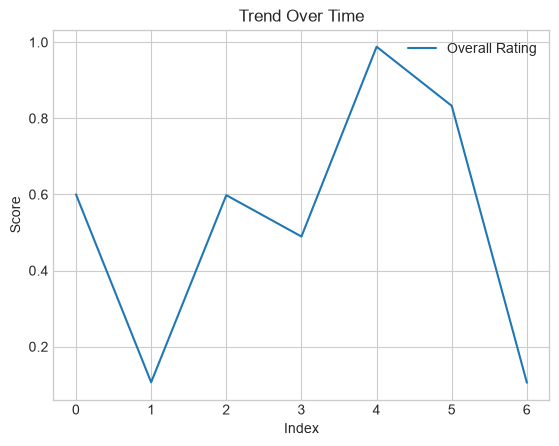

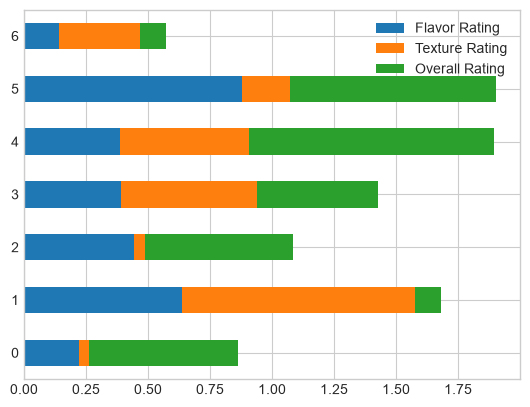

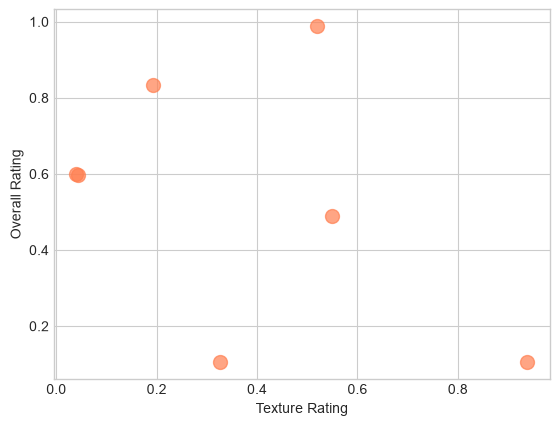

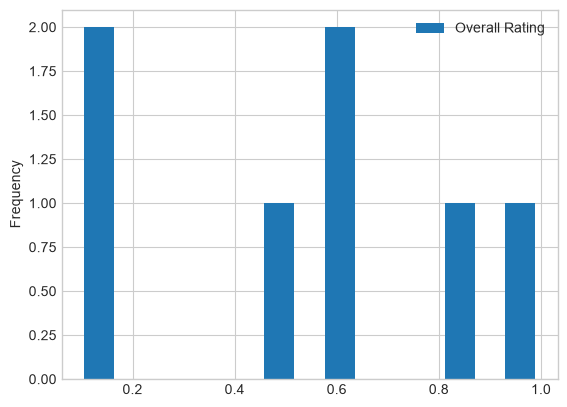

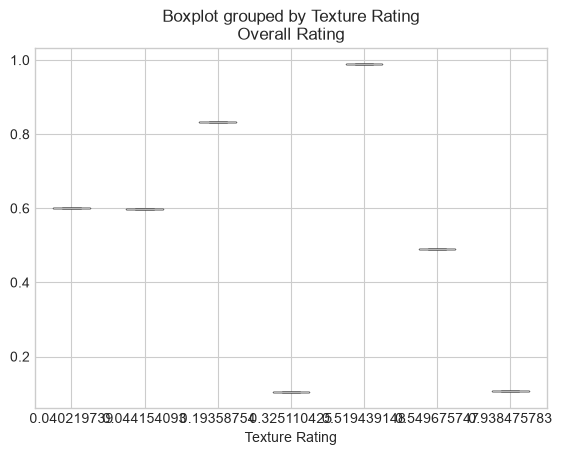

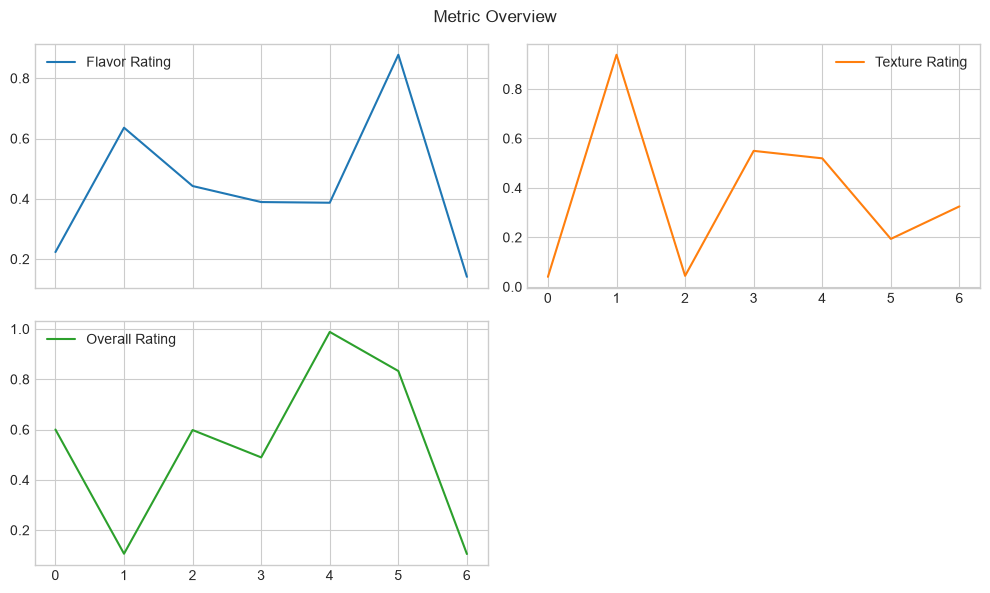

In [50]:
# 1. Styling & Plot Theme
df = pd.read_csv("Ice Cream Ratings.csv")
plt.style.use("seaborn-v0_8-whitegrid")

# 2. Key Exploratory Plots
df.plot.line(
    y="Overall Rating",
    title="Trend Over Time",
    xlabel="Index",
    ylabel="Score",
)
df.plot.barh(stacked=True, rot=0)
df.plot.scatter(
    x="Texture Rating", y="Overall Rating", s=100, c="coral", alpha=0.7
)
df.plot.hist(column="Overall Rating", bins=15, grid=True)
df.boxplot(column="Overall Rating", by="Texture Rating")

# 3. Subplot Grid & Exporting
df.plot(subplots=True, layout=(2, 2), figsize=(10, 6), title="Metric Overview")
plt.tight_layout()
plt.savefig("eda_summary.png", bbox_inches="tight")
plt.show()

### 8. Data Cleaning and Text Standardization

* `df.drop_duplicates(subset=['col'], keep='first')` — Removes duplicate rows (optionally targeting specific key columns).
* `df.drop(columns=['col1', 'col2'])` — Removes specified columns from the DataFrame.
* `df['col'].str.strip('chars')` — Trims whitespace or specified leading/trailing characters from strings.
* `df['col'].str.replace('regex_pat', 'rep', regex=True)` — Replaces matching regex patterns across text values.
* `df['col'].str.split('delimiter', expand=True)` — Splits single text columns into multiple distinct columns.
* `df['col'].map({'Old': 'New'})` — Replaces values in a Series using an explicit replacement mapping dictionary.
* `df.isna()` / `df.notna()` — Checks for null/missing values, returning boolean masks across rows/columns.
* `df.dropna(subset=['col'])` — Removes rows where target columns contain missing (`NaN`) values.
* `df.fillna(value)` — Replaces missing values with a scalar, summary statistic, or mapping dictionary.
* `pd.to_numeric(df['col'], errors='coerce')` — Converts dirty string numbers to numeric floats, coercing invalid text to `NaN`.
* `df[df['col'] != 'Val']` — Vectorized row removal based on conditions.
* `df['col'].map({'Yes': 'Y', 'No': 'N'})` — Standardizes inconsistent boolean response entries.
* `df['col'].apply(lambda x: ...)`— Applies a custom, one-line transformation function to every individual value in a Series.


In [51]:
# 1. Ingestion & Duplicate hygiene
df = pd.read_excel("Customer Call List.xlsx")
df = df.drop_duplicates()
df = df.drop(columns=["Not_Useful_Column"], errors="ignore")

# 2. Text standardization & Phone formatting
df["Last_Name"] = df["Last_Name"].str.strip("123._/")
df["Phone_Number"] = (
    df["Phone_Number"].astype(str).str.replace(r"[^0-9]", "", regex=True)
)
df['Phone_Number'] = df['Phone_Number'].apply(lambda x: str(x))
df["Phone_Number"] = df["Phone_Number"].apply(
    lambda x: f"{x[0:3]}-{x[3:6]}-{x[6:10]}" if len(x) == 10 else np.nan
)

# 3. Address splitting & Categorical mapping
df[["Street_Address", "State", "Zip_Code"]] = df["Address"].str.split(
    ",", n=2, expand=True
)
df["Paying Customer"] = df["Paying Customer"].map({"Yes": "Y", "No": "N"})
df["Do_Not_Contact"] = df["Do_Not_Contact"].map({"Yes": "Y", "No": "N"})

# 4. Missing value cleanup & Vectorized business rules
df = df.replace(["N/a", "na", "--", ""], np.nan)
df = df.dropna(subset=["Phone_Number"])
df = df[df["Do_Not_Contact"] != "Y"].reset_index(drop=True)
df = df.drop(columns=["Address"])

### 9. Exploratory Data Analysis (EDA) Workflow

* `pd.set_option('display.float_format', lambda x: '%.2f' % x)` — Suppresses scientific notation across numeric outputs.
* `df.isnull().sum()` — Quantifies missing/null values per column.
* `df.select_dtypes(include=['number', 'object'])` — Filters columns by numeric or categorical types.
* `df.nlargest(n, 'col')` / `df.nsmallest(n, 'col')` — Returns top or bottom `n` records by a specific column without sorting the entire DataFrame.
* `df.corr(numeric_only=True)` — Computes pairwise Pearson correlation coefficients between numeric features.
* `sns.heatmap(matrix, annot=True)` — Renders a visual matrix to spot collinearity or high correlations.
* `df.transpose()` (or `df.T`) — Swaps rows and columns

Rank                           0
CCA3                           0
Country                        0
Capital                        0
Continent                      0
2022 Population                4
2020 Population                1
2015 Population                4
2010 Population                7
2000 Population                7
1990 Population                5
1980 Population                5
1970 Population                4
Area (km²)                     2
Density (per km²)              4
Growth Rate                    2
World Population Percentage    0
dtype: int64
['CCA3', 'Country', 'Capital', 'Continent']


C:\Users\bexru\AppData\Local\Temp\ipykernel_17456\375024606.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


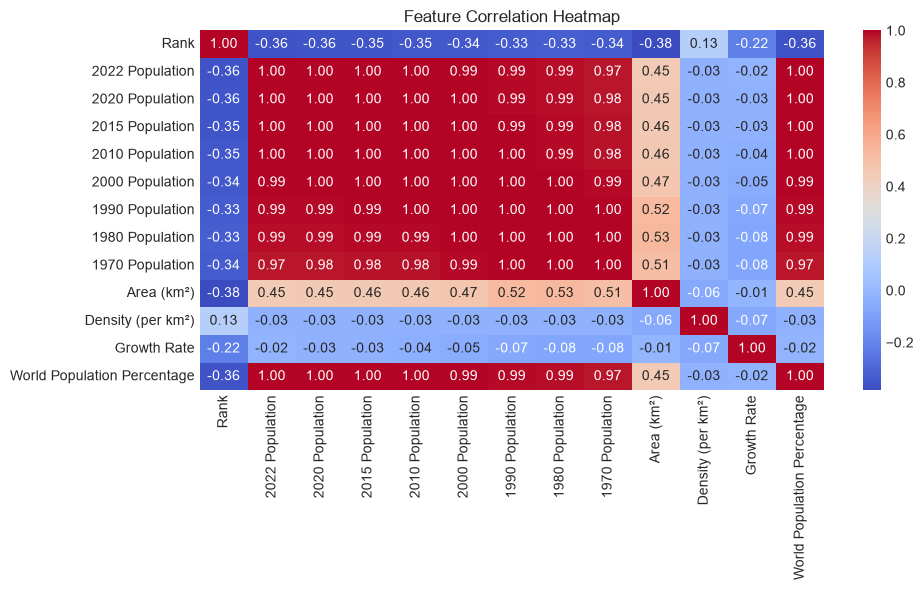

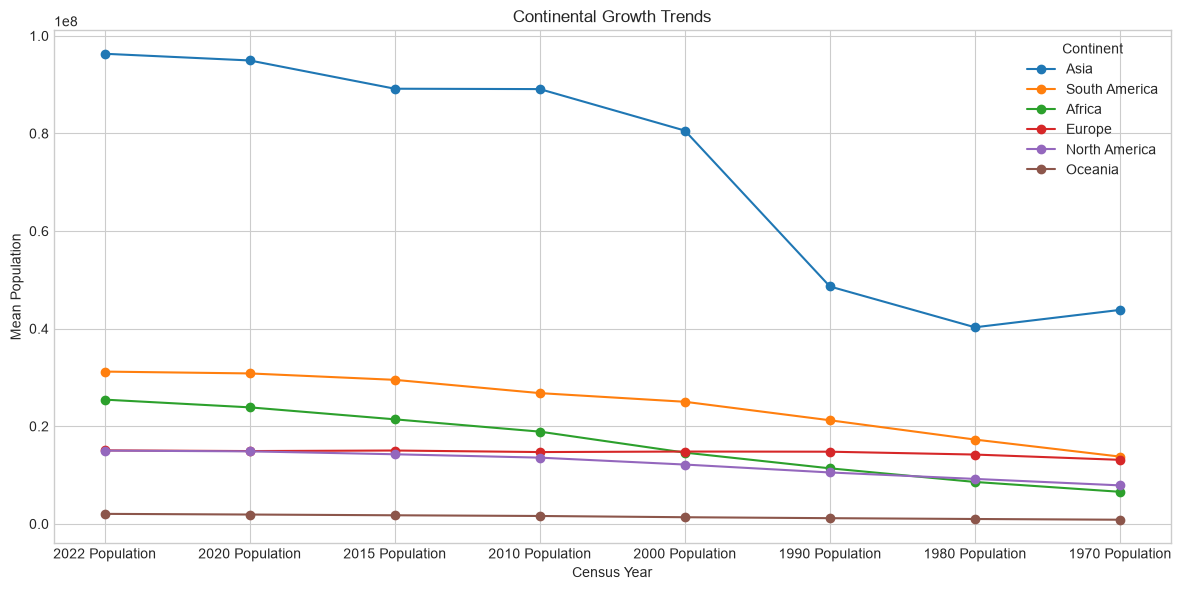

In [52]:
# 1. Formatting & Quick Diagnostics
df = pd.read_csv('world_population.csv')
pd.set_option("display.float_format", lambda x: "%.2f" % x)
print(df.isnull().sum())
print(df.select_dtypes(include="object").columns.tolist())

# 2. Top & Bottom Business Outliers (Fast ranking)
top_5_populated = df.nlargest(5, "2022 Population")[["Country", "2022 Population"]]
bottom_5_populated = df.nsmallest(5, "2022 Population")[["Country", "2022 Population"]]

# 3. Correlation Matrix & Heatmap
plt.figure(figsize=(10, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 4. Grouped Trends over Time (Transpose + Multi-Line Plot)
year_cols = [col for col in df.columns if "Population" in col and "World" not in col]
trend_df = (
    df.groupby("Continent")[year_cols]
    .mean(numeric_only=True)
    .sort_values(by="2022 Population", ascending=False)
    .T
)

trend_df.plot(figsize=(12, 6), marker="o", title="Continental Growth Trends")
plt.xlabel("Census Year")
plt.ylabel("Mean Population")
plt.grid(True)
plt.tight_layout()
plt.show()